In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# READING AND LOADING DATASET

df = pd.read_csv('/Users/manurajgoel/Desktop/MLPRACTICAL/COURSE MODELS/house_dataset.csv')
df.head()

,area_sqft,bedrooms,age,location_score,price
0,3774,1,21,9.38,958091.01
1,1460,1,48,9.77,-9125.04
2,1894,1,41,9.96,217005.95
3,1730,3,5,1.50,632440.85
4,1695,1,14,7.63,480103.64


In [3]:
# To know the number of rows and columns
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_sqft       200 non-null    int64  
 1   bedrooms        200 non-null    int64  
 2   age             200 non-null    int64  
 3   location_score  200 non-null    float64
 4   price           200 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 7.9 KB


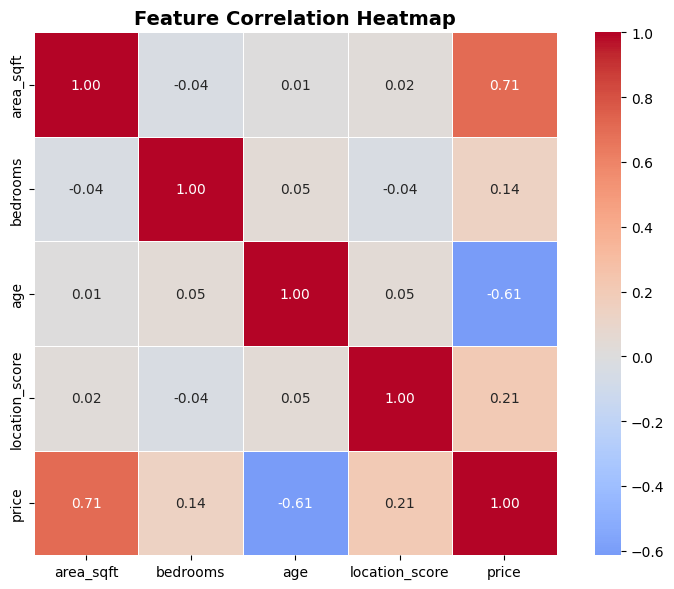

In [5]:
# Plotting HEATMAP
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,            # show numbers on the heatmap
    fmt='.2f',             # 2 decimal places
    cmap='coolwarm',       # colour scheme: red = positive, blue = negative
    center=0,              # centre the colourmap at 0
    linewidths=0.5,
    square=True
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# SELECTING INPUT AND OUTPUT

# drop is used to remove 'price' column from input features(X)
# .values is used to convert it into numpy array

X = df.drop("price", axis = 1).values
y = df['price'].values

In [7]:
# TRAIN TEST SPLITTING DATASET

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# FEATURE SCALING
# StandarScaler : transforms each feature to have mean=0, std=1
# It is imp as features have very different scales
# eg: area is in thousands, bedroom is btw 1-15

scaler = StandardScaler()

In [9]:
X_train_scaled = scaler.fit_transform(X_train)

# fit -> learns mean and std from training data
# transform -> applies the scaling

X_test_scaled = scaler.transform(X_test)
# we didn't use fit on test datset as we want test data to remian unseen

In [10]:
# CREATING A LINEAR REGRESSION MODEL

model = LinearRegression()

In [11]:
# TRAINING THE MODEL

model.fit(X_train_scaled, y_train)

# and now we will train the model on scaled data
# fit() trains the model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred = model.predict(X_test_scaled)

# predict prices for unseen houses

In [13]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("Mean Squared Error", mse)
print("Root Mean Squared Error", rmse)
print("Mean Absolute Error", mae)
print("R2 Score:", r2)

Mean Squared Error 2448632141.3071456
Root Mean Squared Error 49483.65529452271
Mean Absolute Error 39659.73723693673
R2 Score: 0.9765210381641909


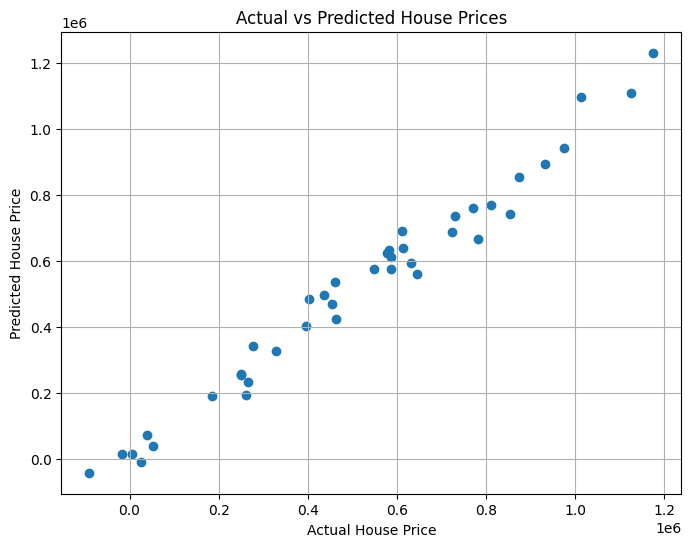

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

In [15]:
print("Weights:", model.coef_)
print("Bias (Intercept):", model.intercept_)

Weights: [ 233823.49168124   69737.28309726 -208375.10467875   77349.27607727]
Bias (Intercept): 519765.997125


In [16]:
# PREDICTION 

# giving house details
my_house = np.array([[1894, 1, 41, 9.96]])

# scaling the input
my_house_scaled = scaler.transform(my_house)

# predicting the price
predicted_price = model.predict(my_house_scaled)

# printing the price
print("Predicted House Price:", predicted_price[0])


# ACTUAL : 217005.95
# PREDICTED : 223389.88

Predicted House Price: 223389.88601223304
